In [1]:
from pathlib import Path
import json

import mlflow
import pickle

import pandas as pd
import numpy as np
import torch
from torch.utils.data import TensorDataset, DataLoader
from numpy.typing import NDArray

import seaborn as sns
sns.set_theme(style="whitegrid")
import matplotlib.pyplot as plt

import shap
from functools import partial

In [2]:
DATA_PATH = Path("../../data/processed")
EXPERIMENT_NAME = "fs_06_load_calendar_future_weather"
OUTPUT_DIR = DATA_PATH / "ml_data" / EXPERIMENT_NAME

X_TRAIN_PATH = OUTPUT_DIR / "X_train.npy"
X_TEST_PATH = OUTPUT_DIR / "X_test.npy"

WINDOW_SIZE = 4*24*7 # 672

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

## First: Start the MLFlow-Server for logging the experiments

Run the following command: 

Powershell:

mlflow server ` 
    --backend-store-uri sqlite:///mlflow.db ` 
    --default-artifact-root ./mlartifacts/  


Bash / Git Bash / WSL / Linux / macOS
mlflow server \
  --backend-store-uri sqlite:///mlflow.db \
  --default-artifact-root ./mlartifacts


In [3]:
mlflow.set_tracking_uri("http://127.0.0.1:5000")

## Load the best models (LSTM, Bayesian LSTM, Propeht) and Perfomance Metrics

In [4]:
LSTM_RUN_ID = "9de69e1bb0844ca29f3267bca6f7674e"
BAYESIAN_LSTM_RUN_ID = "2ccd3a12be4d4ec484be5af5fc8ab4e3"
PROPHET_RUN_ID = "73f7dd056c9c4b38907b476f7bf47615"

In [5]:
mlflow.set_experiment("load_forecasting_bayesian_lstm")

ranked_checkpoints = mlflow.search_logged_models(
    filter_string=f"source_run_id='{BAYESIAN_LSTM_RUN_ID}'",
    order_by=[{"field_name": "metrics.val_nll", "ascending": True}],
    output_format="list",
)

best_checkpoint = ranked_checkpoints[0]

baysian_lstm = mlflow.pytorch.load_model(best_checkpoint.model_uri) # pyright: ignore

In [6]:
mlflow.set_experiment("load_forecasting_vanilla_lstm")

ranked_checkpoints = mlflow.search_logged_models(
    filter_string=f"source_run_id='{LSTM_RUN_ID}'",
    order_by=[{"field_name": "metrics.val_mse", "ascending": True}],
    output_format="list",
)

best_checkpoint = ranked_checkpoints[0]

lstm = mlflow.pytorch.load_model(best_checkpoint.model_uri) # pyright: ignore

In [7]:
mlflow.set_experiment("load_forecasting_prophet")

ranked_checkpoints = mlflow.search_logged_models(
    filter_string=f"source_run_id='{PROPHET_RUN_ID}'",
    order_by=[{"field_name": "metrics.val_mse", "ascending": True}],
    output_format="list",
)

best_checkpoint = ranked_checkpoints[0]

prophet_model = mlflow.prophet.load_model(best_checkpoint.model_uri) # pyright: ignore

## SHAP Calculation

In [8]:
X_train = np.load(X_TRAIN_PATH)
X_test = np.load(X_TEST_PATH)

with open(OUTPUT_DIR / "scalers" / "y_scaler.pkl", "rb") as f:
    y_scaler = pickle.load(f)

with open(OUTPUT_DIR / "meta.json", "r", encoding="utf-8") as f:
    meta = json.load(f)

In [ ]:
def predict_fn(x_np, model, device, y_scaler=None, bayesian=False):
    """Higher order funciton that calls LSTM type models"""
    model.eval()

    x_np = np.asarray(x_np, dtype=np.float32)
    x_t = torch.from_numpy(x_np).to(device)

    with torch.no_grad():
        y = model(x_t)

        if bayesian:
            mu, var_raw = torch.chunk(y, 2, dim=-1)
            y = mu

    y_np = y.detach().cpu().numpy()
    # print(y_np.shape)
    
    if y_scaler is not None:
        _, h = y.shape
        y_np = y_scaler.inverse_transform(y.cpu().reshape(-1,1)).reshape(-1, h)
    return y_np 

class FeatureGroupedTimeSeriesMasker:
    def __init__(self, background_X):
        self.bg = np.asarray(background_X, dtype=np.float32)
        if self.bg.ndim != 3:
            raise ValueError("background_X must be (n_bg, T, F)")

        self.T = self.bg.shape[1]
        self.F = self.bg.shape[2]

        # one mask row, F grouped features
        self.shape = (len(self.bg), self.F)


    def __call__(self, mask, x):
        x = np.asarray(x, dtype=np.float32)
        if x.shape != (self.T, self.F):
            raise ValueError(f"x must be (T,F)=({self.T},{self.F}), got {x.shape}")

        mask = np.asarray(mask, dtype=bool).reshape(-1)
        if mask.shape != (self.F,):
            raise ValueError(f"mask must flatten to ({self.F},), got {mask.shape}")

        masked = np.repeat(x[None, :, :], len(self.bg), axis=0)  # (n_bg, T, F)

        for f in range(self.F):
            if not mask[f]:
                masked[:, :, f] = self.bg[:, :, f]

        return masked

    def mask_shapes(self, x):
        # tell SHAP the explanation has F grouped features
        return [(self.F,)]

lstm_predict_fn_for_shap = partial(
    predict_fn,
    model=lstm,
    device=DEVICE,
    y_scaler=y_scaler,
    bayesian=False
)

baysian_lstm_predict_fn_for_shap = partial(
    predict_fn,
    model=baysian_lstm,
    device=DEVICE,
    y_scaler=y_scaler,
    bayesian=True
)

In [ ]:
masker = FeatureGroupedTimeSeriesMasker(X_train[::96][:1000])
lstm_explainer = shap.Explainer(lstm_predict_fn_for_shap, masker, algorithm="exact")
bayesian_lstm_explainer = shap.Explainer(baysian_lstm_predict_fn_for_shap, masker, algorithm="exact")

### SHAP for Vanilla LSTM

In [ ]:
lstm_shap_values = lstm_explainer(X_test[:1])
torch.cuda.empty_cache()

ExactExplainer explainer: 2it [00:25, 25.19s/it]               


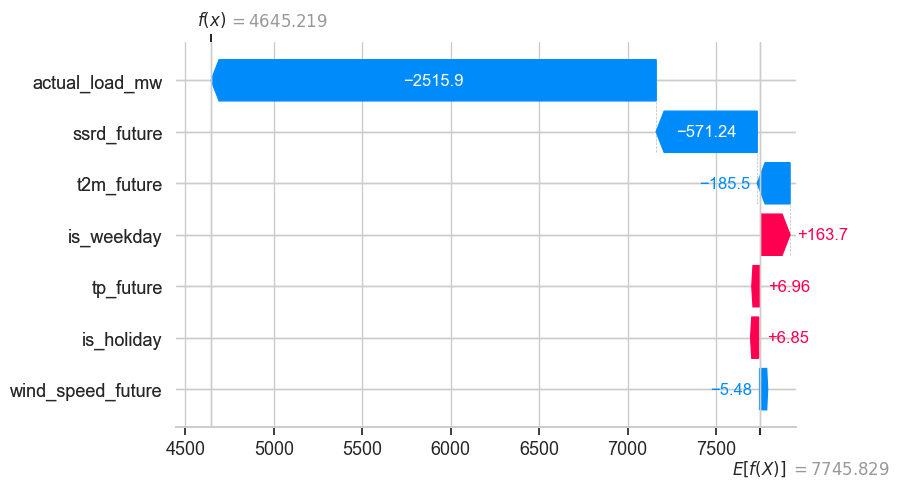

In [ ]:
sample_idx = 0
timestep_idx = 25

values_1d = lstm_shap_values.values[sample_idx][:, timestep_idx]
base_value = lstm_shap_values.base_values[sample_idx][timestep_idx]

exp = shap.Explanation(
    values=values_1d,
    base_values=base_value,
    feature_names=meta["feature_names"],
)

shap.plots.waterfall(exp)


### SHAP for Bayesian LSTM

In [ ]:
bayesian_lstm_shap_values = bayesian_lstm_explainer(X_test[:1])
torch.cuda.empty_cache()

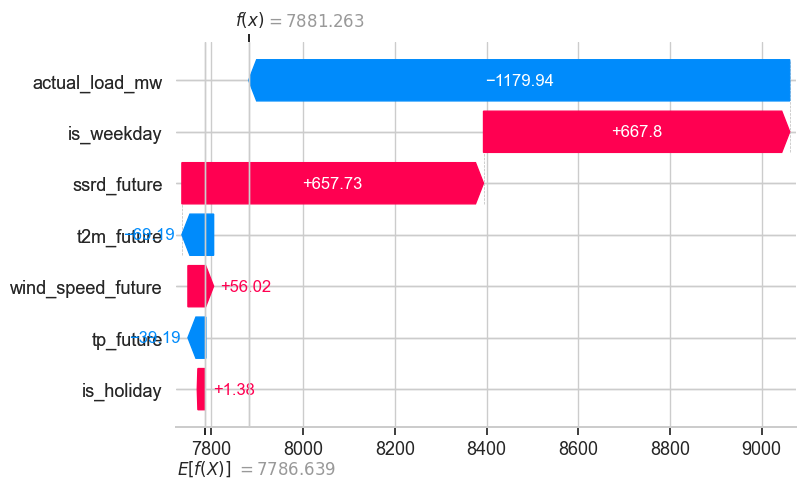

In [ ]:
sample_idx = 0
timestep_idx = 60

values_1d = bayesian_lstm_shap_values.values[sample_idx][:, timestep_idx]
base_value = bayesian_lstm_shap_values.base_values[sample_idx][timestep_idx]

exp = shap.Explanation(
    values=values_1d,
    base_values=base_value,
    feature_names=meta["feature_names"],
)

shap.plots.waterfall(exp)


In [ ]:
shap_samples = []
for s in range(20):
    shap_s = bayesian_lstm_explainer(X_train[:1])   # with stochastic Bayesian forward pass
    shap_samples.append(shap_s.values)

shap_samples = np.vstack(shap_samples)  # [S, N, F, H]
shap_mean = shap_samples.mean(axis=0)
shap_lo = np.percentile(shap_samples, 2.5, axis=0)
shap_hi = np.percentile(shap_samples, 97.5, axis=0)

In [ ]:
timestep_idx = 25
for i, feature in enumerate(meta["feature_names"]):
    print(f"Feature {feature}: Mean Shap {shap_mean[i, timestep_idx]}, (LO: {shap_lo[i, timestep_idx]} - HI {shap_hi[i, timestep_idx]})")

Feature actual_load_mw: Mean Shap -815.4295725608144, (LO: -932.5811339834568 - HI -673.857849765798)
Feature t2m_future: Mean Shap -145.77192037737, (LO: -259.78211193916394 - HI -47.437832006420436)
Feature ssrd_future: Mean Shap 10.913505333141705, (LO: -124.73148861839307 - HI 126.57075045096306)
Feature tp_future: Mean Shap -0.9903046555225401, (LO: -121.25827396830363 - HI 149.7938522066909)
Feature wind_speed_future: Mean Shap 1.6632182309149215, (LO: -33.87351408480782 - HI 49.8124111671136)
Feature is_weekday: Mean Shap 991.4107423966543, (LO: 852.9416142619436 - HI 1104.3155963102633)
Feature is_holiday: Mean Shap -18.66269435227087, (LO: -22.573829786955475 - HI -15.469934900396225)


### SHAP for Prophet

In [9]:
raw_data = pd.read_parquet(DATA_PATH /  "data_combined.parquet")

raw_data.head()

,actual_load_mw,t2m_future,ssrd_future,tp_future,wind_speed_future,is_weekday,is_holiday
period,,,,,,,
2018-10-01 00:00:00+00:00,5256.0,277.421722,0.0,0.000000e+00,1.758537,True,0
2018-10-01 00:15:00+00:00,5204.0,277.421722,0.0,0.000000e+00,1.758537,True,0
2018-10-01 00:30:00+00:00,5178.0,277.421722,0.0,0.000000e+00,1.758537,True,0
2018-10-01 00:45:00+00:00,5151.0,277.421722,0.0,0.000000e+00,1.758537,True,0
2018-10-01 01:00:00+00:00,5187.0,277.252350,0.0,6.201566e-08,1.709355,True,0


In [10]:
start = pd.Timestamp(meta["test_date_range"]["start"])
end   = pd.Timestamp(meta["test_date_range"]["end"])

test_raw = raw_data.loc[start:end].copy()   # 40630 rows
w = meta["window_size"]                     # 672
h = meta["forecast_horizon"]                # 96
n_seq = X_test.shape[0]                     # 39863

test_df = test_raw[w-1 : len(test_raw)-h]   # len = 39863

def preprocess_to_prophet_df(df, target):
    prophet_df = df.rename(columns={target: "y"})
    prophet_df["ds"] = prophet_df.index
    prophet_df["ds"]=prophet_df["ds"].dt.tz_convert(None)
    return prophet_df

In [19]:
prophet_df = preprocess_to_prophet_df(test_df, target="actual_load_mw")
reg_cols = [c for c in prophet_df.columns if c not in ["ds", "y"]]

X_reg_df = prophet_df[reg_cols].copy()

# force strict numeric matrix for SHAP
X_reg = prophet_df[reg_cols].to_numpy(np.float64)
bg_reg = X_reg

def predict_fixed_ds(x_reg_np, ds, reg_cols):
    x_reg_df = pd.DataFrame(x_reg_np, columns=reg_cols)
    model_df = x_reg_df.copy()
    model_df["ds"] = pd.to_datetime(np.repeat(ds, len(x_reg_df)))
    return prophet_model.predict(model_df)["yhat"].to_numpy()

i = 9000
f_i = partial(predict_fixed_ds, ds=prophet_df["ds"].iloc[i], reg_cols=reg_cols)
explainer_i = shap.Explainer(f_i, masker=bg_reg, algorithm="exact")
sv_i = explainer_i(X_reg[[i]])


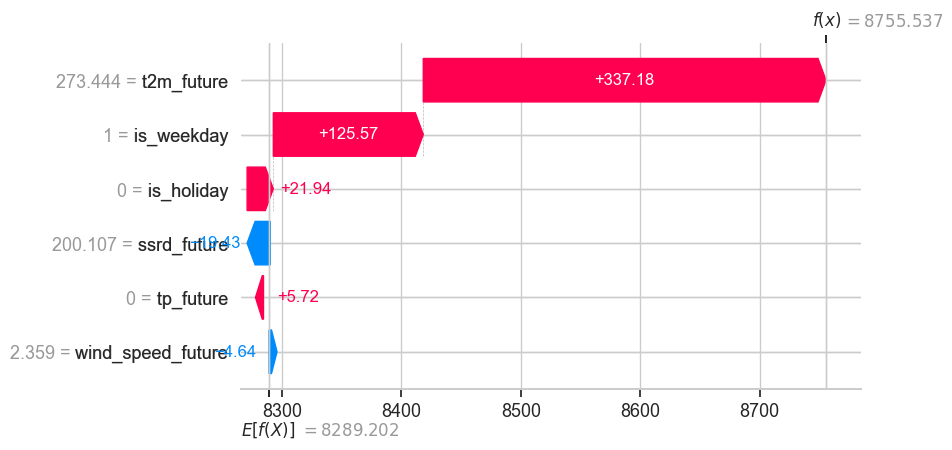

In [20]:
exp = shap.Explanation(
    values=sv_i[0],
    base_values=sv_i.base_values[0],
    feature_names=reg_cols,
)

shap.plots.waterfall(exp)

## Not working / unstable and crashes sometimes

In [ ]:
class ProhpetFeatureMasker():
    def __init__(self, background_df, target):
        self.bg = background_df

        self.input_cols = background_df.columns
        self.reg_cols = [c for c in self.bg.columns if c not in ["ds", target]]

        self.shape = (1, len(self.reg_cols))

    def __call__(self, mask, x):
        x_row = pd.DataFrame([x], columns=self.input_cols)

        mask = np.asarray(mask, dtype=bool).ravel()

        masked = pd.concat([x_row] * len(self.bg), ignore_index=True)

        for col, keep in zip(self.reg_cols, mask):
            if not keep: # all false values in the mask indicate a feature to mask
                masked.loc[:, col] = self.bg.loc[:, col].to_numpy()
        
        return masked 


def prophet_predict_fn_for_shap(x_np, input_cols, ds):
    x_df = pd.DataFrame(x_np, columns=input_cols)
    x_df["ds"] = pd.to_datetime(np.repeat(ds, len(x_df)))
    
    y_hat = prophet_model.predict(x_df)["yhat"].values
    

    return y_hat

i = 1
prophet_df = preprocess_to_prophet_df(test_df, target="actual_load_mw")

ds=prophet_df["ds"].iloc[i]

prophet_predict_fn = partial(
    prophet_predict_fn_for_shap,
    ds=ds,
    input_cols= ['t2m_future', 'ssrd_future', 'tp_future', 'wind_speed_future',
       'is_weekday', 'is_holiday']#prophet_df.columns
)

prophet_masker = ProhpetFeatureMasker(
    background_df=prophet_df.iloc[:100].drop(columns=["y","ds"]),
    target="y"
)

prophet_explainer = shap.Explainer(prophet_predict_fn, masker=prophet_masker, algorithm="exact")

: 

In [ ]:
prophet_shap_values = prophet_explainer(prophet_df.iloc[[i]].drop(columns=["y","ds"]))
prophet_shap_values

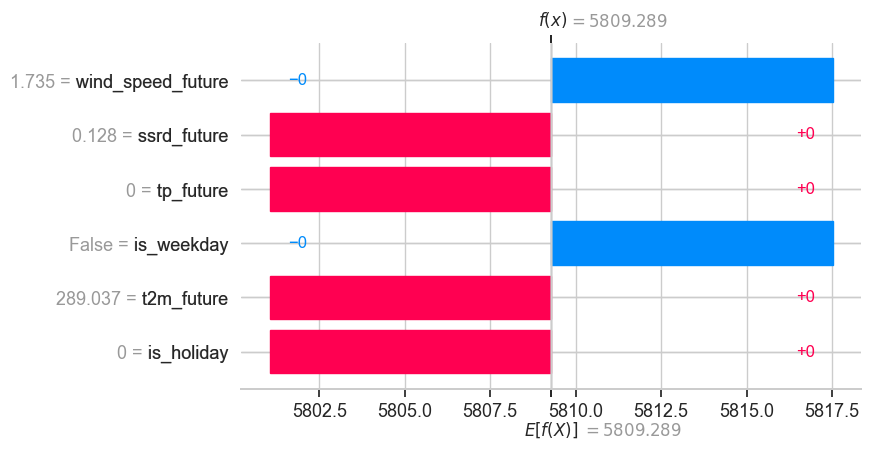

In [21]:
shap.plots.waterfall(prophet_shap_values[0])